### Mini-RAG

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Step 1 : Load a pre-rained model that converts text to vectors
model = SentenceTransformer("all-MiniLM-L6-v2") # Lightweight, fast, good for beginners

# Step 2: In real world there will be 1000's of pdf's, docs etc
docs = [
    "Our company provides 26 weeks of maternity leave.",
    "Employees are eligible for 2 weeks of paternity leave.",
    "The office remains closed on all national holidays."
]

# Step 3: Convert each document to vector (embedding)
embeddings = model.encode(docs)

# Step 4: Convert users question into the same vector space
query = "What is the maternity leave policy?"
query_emb = model.encode([query])

# Step 5: Find which document vector is most similar to query vector
scores = cosine_similarity(query_emb, embeddings)[0] # Compare angles between the vectors
top_idx = int(np.argmax(scores)) # Find the best match

# Note: In real RAG, you usually keep top_k > 1 (e.g., top 3 chunks)
# This gives the LLM more context and reduces incomplete answers.
print(f"Query: ", query)
print(f"Most relavant docs: ", docs[top_idx])
print(f"Similarity score: ", np.round(scores, 2))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Query:  What is the maternity leave policy?
Most relavant docs:  Our company provides 26 weeks of maternity leave.
Similarity score:  [0.72 0.57 0.16]


### Visualize the embeddings

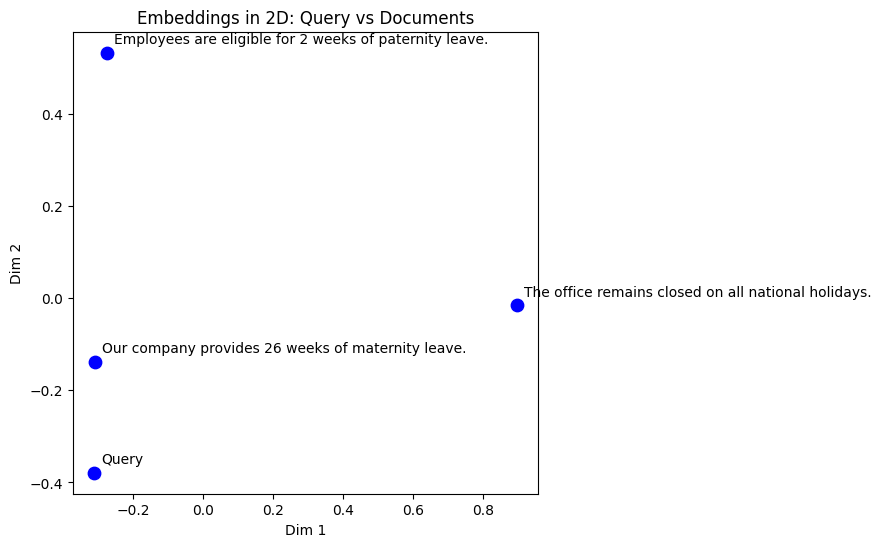

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(np.vstack([embeddings, query_emb]))
labels = docs + ["Query"]
plt.figure(figsize=(6,6))
plt.scatter(reduced[:,0], reduced[:,1], c="blue", s=80)
for i, label in enumerate(labels):
    plt.annotate(label, (reduced[i,0]+0.02, reduced[i,1]+0.02))
plt.title("Embeddings in 2D: Query vs Documents")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [3]:
pip install sentence-transformers faiss-cpu qdrant-client chromadb rank-bm25


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6

...

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")
docs = [
    "Our HR policy allows 26 weeks of maternity leave.",
    "Employees get 2 weeks of paternity leave.",
    "Office is closed on all national holidays.",
    "Annual leave must be approved by the reporting manager.",
    "Unused casual leave cannot be carried forward to the next year.",
    "Employees are entitled to 12 days of sick leave per year.",
    "Work-from-home requests should be submitted at least one day in advance.",
    "New employees must complete onboarding within their first week.",
    "Performance reviews are conducted twice a year.",
    "Employees must inform HR immediately after a change in marital status.",
    "Medical insurance coverage begins after the probation period ends.",
    "The probation period for new hires is six months.",
    "Late attendance more than three times a month may lead to a warning.",
    "Employees should wear their ID cards at all times inside the office.",
    "Exit interviews are mandatory for all resigning employees.",

    "All employees must reset their system passwords every 90 days.",
    "VPN access is required when working remotely.",
    "Do not share your company login credentials with anyone.",
    "All company laptops must have antivirus software installed.",
    "USB drives are blocked on finance department computers.",
    "Employees must report phishing emails to the IT helpdesk.",
    "Two-factor authentication is mandatory for email access.",
    "Software installation requests must be approved by IT.",
    "Company data should only be stored on approved cloud platforms.",
    "Public Wi-Fi should not be used to access confidential systems.",
    "Screens must be locked before leaving the workstation.",
    "Only IT administrators can access production servers.",
    "Employees must not use personal email for official communication.",
    "System maintenance is scheduled every second Saturday.",
    "All security incidents must be reported within one hour.",

    "Travel reimbursement claims must be submitted within 10 days.",
    "Meal expenses during business travel are reimbursable up to the approved limit.",
    "Finance closes monthly expense reports on the last working day.",
    "All purchases above $500 require manager approval.",
    "Invoices must include the vendor tax identification number.",
    "Salary is credited on the last business day of each month.",
    "Employees should submit tax documents before the fiscal year deadline.",
    "Petty cash can only be used for approved office expenses.",
    "Advance payments must be settled within five working days after travel.",
    "Budget requests for new projects should be sent to finance before quarter end.",
    "Reimbursement for training programs requires proof of completion.",
    "Late submission of expense claims may result in rejection.",
    "Finance does not reimburse personal entertainment expenses.",
    "Procurement requests must include at least two vendor quotations.",
    "Business class travel is allowed only for director-level employees.",

    "Meeting rooms must be booked through the internal calendar system.",
    "Office parking spaces are assigned on a first-come, first-served basis.",
    "Visitors must sign in at the reception desk.",
    "Pantry supplies are restocked every Monday and Thursday.",
    "Employees must keep their desks clean at the end of each day.",
    "Smoking is prohibited inside the office premises.",
    "Emergency evacuation drills are conducted every six months.",
    "The office generator supports only essential systems during power outages.",
    "Courier deliveries should be collected from the admin desk.",
    "Stationery requests must be submitted using the admin portal.",

    "Customer data must not be downloaded to personal devices.",
    "Confidential documents should be shredded before disposal.",
    "Employees must complete cybersecurity training once a year.",
    "Any suspected data breach must be escalated to the security team immediately.",
    "Access cards are deactivated automatically after resignation.",
    "Only authorized staff may enter the server room.",
    "CCTV footage is retained for 30 days unless required for investigation.",
    "Passwords must contain at least 12 characters.",
    "Shared folders should follow role-based access permissions.",
    "Printing confidential contracts requires department head approval.",

    "Project status updates must be shared every Friday.",
    "Teams should document key decisions in the project tracker.",
    "Client meetings require a meeting summary within 24 hours.",
    "Support tickets are prioritized based on severity and business impact.",
    "Critical production issues must be acknowledged within 15 minutes.",
    "Daily stand-up meetings should not exceed 15 minutes.",
    "All code changes must go through peer review before deployment.",
    "Production deployments are not allowed on Fridays after 4 PM.",
    "Backup jobs run automatically every midnight.",
    "Disaster recovery testing is performed once every year."
]
E = model.encode(docs, normalize_embeddings=False)
En = E / np.linalg.norm(E, axis=1, keepdims=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Metric Intuition (dot vs cosine vs L2) + Normalization

In [5]:
from numpy.linalg import norm

def sims(q, M, normalize=False):
    q2 = q.copy()
    M2 = M.copy()
    if normalize:
        q2 = q2 / norm(q2)
        M2 = M2 / norm(M2, axis=1, keepdims=True)
    dot = M2 @ q2
    l2 = norm(M2 - q2, axis=1)
    cos = (M2 @ q2) / (norm(M2,axis=1)*norm(q2))
    return dot, cos, l2

q = model.encode(["What is the maternity leave policy?"])[0]

for title, normalize in [("RAW", False), ("UNIT", True)]:
    dot, cos, l2 = sims(q, E if not normalize else En, normalize)
    print(title,
          "top by DOT:", int(np.argmax(dot)),
          "COS:", int(np.argmax(cos)),
          "L2 (min):", int(np.argmin(l2)))

RAW top by DOT: 0 COS: 0 L2 (min): 0
UNIT top by DOT: 0 COS: 0 L2 (min): 0


###  Flat (exact) vs HNSW (approx) with parameter sweep

In [6]:
import faiss, time

d = En.shape[1]
# Flat IP (cosine with unit vectors)
flat = faiss.IndexFlatIP(d); flat.add(En)

# HNSW
hnsw = faiss.IndexHNSWFlat(d, 32)  # M=32
hnsw.hnsw.efConstruction = 200
hnsw.add(En)

def bench(index, qtext, ef=None, k=5):
    qv = model.encode([qtext], normalize_embeddings=True)
    if ef is not None and hasattr(index, "hnsw"):
        index.hnsw.efSearch = ef
    t0 = time.time()
    D, I = index.search(qv, k)
    ms = (time.time()-t0)*1000
    return D[0], I[0], ms

goldD, goldI, gold_ms = bench(flat, "maternity leave", k=5)
print("Flat latency (ms):", round(gold_ms,2))
for ef in [16,32,64,128,256]:
    D, I, ms = bench(hnsw, "maternity leave", ef, k=5)
    recall = len(set(I) & set(goldI))/len(goldI)
    print(f"ef={ef:>3}  latency={ms:6.2f} ms  recall@5={recall:.2f}  rankset={list(I)}")


Flat latency (ms): 0.11
ef= 16  latency=  0.10 ms  recall@5=1.00  rankset=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
ef= 32  latency=  0.09 ms  recall@5=1.00  rankset=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
ef= 64  latency=  0.10 ms  recall@5=1.00  rankset=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
ef=128  latency=  0.12 ms  recall@5=1.00  rankset=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
ef=256  latency=  0.10 ms  recall@5=1.00  rankset=[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]


###IVF tuning (nlist, nprobe)

In [7]:
nlist = 64
quantizer = faiss.IndexFlatIP(d)
ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)
ivf.train(En)      # train centroids
ivf.add(En)
qv = model.encode(["holiday policy"], normalize_embeddings=True)
goldD, goldI = flat.search(qv, 5)
for nprobe in [1,2,4,8,16,32]:
    ivf.nprobe = nprobe
    D, I = ivf.search(qv, 5)
    recall = len(set(I[0]) & set(goldI[0]))/5
    print(f"nprobe={nprobe:<2} recall@5={recall:.2f}")

nprobe=1  recall@5=0.20
nprobe=2  recall@5=0.40
nprobe=4  recall@5=0.80
nprobe=8  recall@5=1.00
nprobe=16 recall@5=1.00
nprobe=32 recall@5=1.00


###PQ compression: memory vs recall

In [8]:
m = 16  # sub-quantizers
# Using 4 bits per sub-vector (2^4 = 16 clusters) because our dataset is small (75 docs).
# 8 bits would require at least 256 documents to train.
pq = faiss.IndexPQ(d, m, 4)
pq.train(En); pq.add(En)

q = model.encode(["maternity leave"], normalize_embeddings=True)
Dg, Ig = flat.search(q, 5)
Dp, Ip = pq.search(q, 5)

recall = len(set(Ip[0]) & set(Ig[0]))/5
print("PQ recall@5:", recall)

# Memory math (rough)
bytes_float = En.size * 4
bytes_pq = En.shape[0] * m * (4/8)  # 4 bits = 0.5 bytes
print(f"Float mem ≈ {bytes_float/1e6:.4f} MB  vs  PQ codes ≈ {bytes_pq/1e6:.4f} MB")

PQ recall@5: 1.0
Float mem ≈ 0.1152 MB  vs  PQ codes ≈ 0.0006 MB


###Hybrid retrieval (BM25 + Vector)

In [9]:
from rank_bm25 import BM25Okapi
tokens = [d.lower().split() for d in docs]
bm25 = BM25Okapi(tokens)
def hybrid(query, alpha=0.5, k=5):
    # vector scores
    qv = model.encode([query], normalize_embeddings=True)
    Dv, Iv = flat.search(qv, k)
    vec_scores = {i: float(s) for i, s in zip(Iv[0], Dv[0])}

    # bm25 scores
    bm = bm25.get_scores(query.lower().split())

    # combine (min-max scale for demo)
    bm_norm = (bm - bm.min()) / (bm.max() - bm.min() + 1e-9)
    scores = {i: alpha*vec_scores.get(i,0) + (1-alpha)*bm_norm[i] for i in range(len(docs))}
    top = sorted(scores.items(), key=lambda x:x[1], reverse=True)[:k]
    return top
print(hybrid("leave policy", alpha=0.6))

[(0, np.float64(0.7034550784992761)), (3, np.float64(0.6158796279547778)), (4, np.float64(0.549999804260559)), (5, np.float64(0.5246706852935028)), (14, np.float64(0.23316637873649596))]


### demo re-ranking and all


In [10]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Step 1: Small HR knowledge base (pretend these came from company policy PDFs)

docs = [
    "Our company provides 26 weeks of maternity leave as per the Maternity Benefit Act, 1961.",
    "Employees are eligible for 15 days of paternity leave as per company policy.",
    "The office remains closed on all national holidays including Diwali, Holi, and Independence Day.",
    "Probationary employees are entitled to limited benefits until confirmation as per Indian labour laws."
]

#Step 2: Chunking
chunks = docs #In practice, split into 300-400 word chunks

# Step 3 : Embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
E = model.encode(chunks, normalize_embeddings=True)

#Step 4: User query
query = "What is the paternity leave duration?"
q_emb = model.encode([query], normalize_embeddings=True)

# STep 5: vector search (retrieve top-k)
k = 3
scores = cosine_similarity(q_emb, E)[0]
top_idx = np.argsort(scores)[::-1][:k]
retrieved = [(chunks[i], scores[i]) for i in top_idx]
print("retrieved chunks (before re-ranking): ")
for text, score in retrieved:
  print(f"Score: {score:.3f} | {text}")

# Step 6: Cross-encoder Re-Ranking for presicision
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2") # Changed from v3 to v2
rerank_scores = []
for doc, _ in retrieved:
  score = cross_encoder.predict([[query, doc]])[0]
  rerank_scores.append((doc, score))
reranked = sorted(rerank_scores, key=lambda x: x[1], reverse=True)
print("\nRe-ranked Chunks (after cross-encoder):")
for text, score in reranked:
    print(f"Re-rank Score={score:.3f} | {text}")

# Step 7: inject context into llm style prompt
context = "\n".join([f"Doc {i+1}: {doc}" for i, (doc, _) in enumerate(reranked)])
prompt = f"""Question: {query}
Context:
{context}
Answer based only on the provided context and cite your source:"""
print(f"\nFinal Prompt to LLM:\n{prompt}")

# Step 8: Stimulate LLM generation

def generate_answer(query, context):
  return "Based on our company HR policy, employees are eligible for 15 days of paternity leave. (Source: Doc 1 - HR Policy)"
final_answer = generate_answer(query, context)
print(f"\nFinal Answer: {final_answer}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


retrieved chunks (before re-ranking): 
Score: 0.779 | Employees are eligible for 15 days of paternity leave as per company policy.
Score: 0.516 | Our company provides 26 weeks of maternity leave as per the Maternity Benefit Act, 1961.
Score: 0.234 | Probationary employees are entitled to limited benefits until confirmation as per Indian labour laws.


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]


Re-ranked Chunks (after cross-encoder):
Re-rank Score=4.288 | Employees are eligible for 15 days of paternity leave as per company policy.
Re-rank Score=-6.242 | Our company provides 26 weeks of maternity leave as per the Maternity Benefit Act, 1961.
Re-rank Score=-11.206 | Probationary employees are entitled to limited benefits until confirmation as per Indian labour laws.

Final Prompt to LLM:
Question: What is the paternity leave duration?
Context:
Doc 1: Employees are eligible for 15 days of paternity leave as per company policy.
Doc 2: Our company provides 26 weeks of maternity leave as per the Maternity Benefit Act, 1961.
Doc 3: Probationary employees are entitled to limited benefits until confirmation as per Indian labour laws.
Answer based only on the provided context and cite your source:

Final Answer: Based on our company HR policy, employees are eligible for 15 days of paternity leave. (Source: Doc 1 - HR Policy)


### Production

In [11]:
from functools import lru_cache
import time

@lru_cache(maxsize=1000)
def retrieve(query, department=None):
  if department:
    # Route to specific shards
    index = get_department_index(department)
  else:
    index = global_index

  try:
    results = index.search(query, k=5)
    return results
  except Exception as e:
    print(f"Search Failed: {e}")
    return []

# Monitor Cache performance
def get_cache_stats():
  info = retrieve.cache_info()
  hit_rate = info.hits / (info.hits + info.misses) if (info.hits + info.misses) > 0 else 0
  return {
      "hit_rate": hit_rate,
      "cache_size": info.currsize,
      "max_size": info.maxsize
  }



### Hybrid search implementation

In [12]:
def hybrid_search(query, alpha=0.7):
  """
  Combine BM25 and vector search to retrieve relevant documents.
  alpha: weight for vector search(0.7 = 70% semantic and 30% keyword
  """
  # get for keyword-based result
  bm25_scores = bm25_index.search(query, k=20)

  # get semantic results
  vector_scores = vector_index.search(query, k=20)

  # Normalize
  bm25_normalized = normalize_scores(bm25_score)
  vector_normalized = normalize_scores(vector_score)

  # Weighted combination
  final_score = {}
  all_doc_ids = set(bm25_normalized.keys()) | set(vector_normalized.keys())

  for doc_id in all_doc_ids:
    bm25_score = bm25_normalized.get(doc_id, 0)
    vector_score = vector_normalized.get(doc_id, 0)
    final_scores[doc_id] = alpha * vector_score + (1-alpha) * bm25_score

  # REturn Top-k results
  return sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:10]

### Customer Support RAG Agent

In [13]:
from sentence_transformers import SentenceTransformer
import faiss, numpy as np

# Knowledge base
docs = [
  "HR: Our maternity leave policy is 26 weeks.",
  "Finance: Reimbursements are processed within 7 business days.",
  "Tech: VPN issues can be solved by resetting credentials."
]

# Step 1: Embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
E = model.encode(docs, normalize_embeddings=True)

# Step 2: Build FAISS index
d = E.shape[1]
index = faiss.IndexFlatIP(d)
index.add(E)

# Step 3: Enhanced query fuction with error handleing
def search_knowledge_base(query, top_k=2):
  try:
    q_emb = model.encode([query], normalize_embeddings=True)
    D, I = index.search(q_emb, top_k)

    # Filter valid indices and return results
    retrieved_docs = []
    for i, score in zip(I[0], D[0]):
      if i < len(docs) and score > 0.3:  # Confidence threshold
        retrieved_docs.append({
          "document": docs[i],
          "score": float(score),
          "index": int(i)
          })

        return retrieved_docs

  except Exception as e:
    print(f"Error in search_knowledge_base: {e}")
    return []

# Step 4: Query with access control
def secure_search(query, user_department):
  results = search_knowledge_base(query)

  # Filter by department access
  filtered_results = []
  for result in results:
    doc_dept = result["document"].split(":")[0] # Exact department
    if doc_dept == user_department or user_department == "Admin":
      filtered_results.append(result)

  return filtered_results


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
#Example usage
query = "How long Reimbursements are processed?"
results = secure_search(query, "Finance")
print("Retrieved Docs:", [r["document"] for r in results])
print("Confidence Scores:", [r["score"] for r in results])


Retrieved Docs: ['Finance: Reimbursements are processed within 7 business days.']
Confidence Scores: [0.8310669660568237]
